# Initial Data Exploration

This notebook performs initial exploratory data analysis on NYC TLC trip data.

## Objectives
1. Load and inspect raw data
2. Understand data structure and quality
3. Identify patterns and anomalies
4. Visualize key trends
5. Generate initial insights about hypothesis

In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. Load Data

In [16]:
# Define data paths
RAW_DATA_PATH = Path('../../data/raw')
PROCESSED_DATA_PATH = Path('../../data/processed')

# List available files
raw_files = list(RAW_DATA_PATH.glob('*.parquet'))
print(f"Found {len(raw_files)} raw data files")
print("\nSample files:")
for f in raw_files[:5]:
    print(f"  - {f.name}")

Found 1 raw data files

Sample files:
  - yellow_tripdata_2024-01.parquet


In [17]:
# Load a sample file for initial exploration
# Choose a recent month for yellow taxi
sample_file = [f for f in raw_files if 'yellow' in f.name][0]
print(f"Loading: {sample_file.name}")

df = pd.read_parquet(sample_file)
print(f"\nShape: {df.shape}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

Loading: yellow_tripdata_2024-01.parquet

Shape: (2964624, 19)
Memory usage: 395.82 MB


## 2. Data Structure and Quality

In [18]:
# Display first few rows
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [19]:
# Data types and null values
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee

In [20]:
# Summary statistics
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2.964624e+06,2964624,2964624,2.824462e+06,2.964624e+06,2.824462e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.824462e+06,2.824462e+06
mean,1.754204e+00,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.339281e+00,3.652169e+00,2.069359e+00,1.660179e+02,1.651167e+02,1.161271e+00,1.817506e+01,1.451598e+00,4.833823e-01,3.335870e+00,5.270212e-01,9.756319e-01,2.680150e+01,2.256122e+00,1.411611e-01
min,1.000000e+00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-8.990000e+02,-7.500000e+00,-5.000000e-01,-8.000000e+01,-8.000000e+01,-1.000000e+00,-9.000000e+02,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.538000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.000000e+00,1.680000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.700000e+00,0.000000e+00,1.000000e+00,2.010000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.000000e+00,3.110000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.120000e+00,0.000000e+00,1.000000e+00,2.856000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.000000e+00,3.127223e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.000000e+03,1.425000e+01,4.000000e+00,4.280000e+02,1.159200e+02,1.000000e+00,5.000000e+03,2.500000e+00,1.750000e+00
std,4.325902e-01,NaN,NaN,8.502817e-01,2.254626e+02,9.823219e+00,6.362391e+01,6.931535e+01,5.808686e-01,1.894955e+01,1.804102e+00,1.177600e-01,3.896551e+00,2.128310e+00,2.183645e-01,2.338558e+01,8.232747e-01,4.876239e-01


In [21]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print("Missing Values:")
print(missing_df[missing_df['Percentage'] > 0])

Missing Values:
                      Missing Count  Percentage
store_and_fwd_flag           140162    4.727817
RatecodeID                   140162    4.727817
passenger_count              140162    4.727817
Airport_fee                  140162    4.727817
congestion_surcharge         140162    4.727817


## 3. Temporal Patterns

In [22]:
# Extract temporal features
if 'tpep_pickup_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
elif 'lpep_pickup_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['day'] = df['pickup_datetime'].dt.day

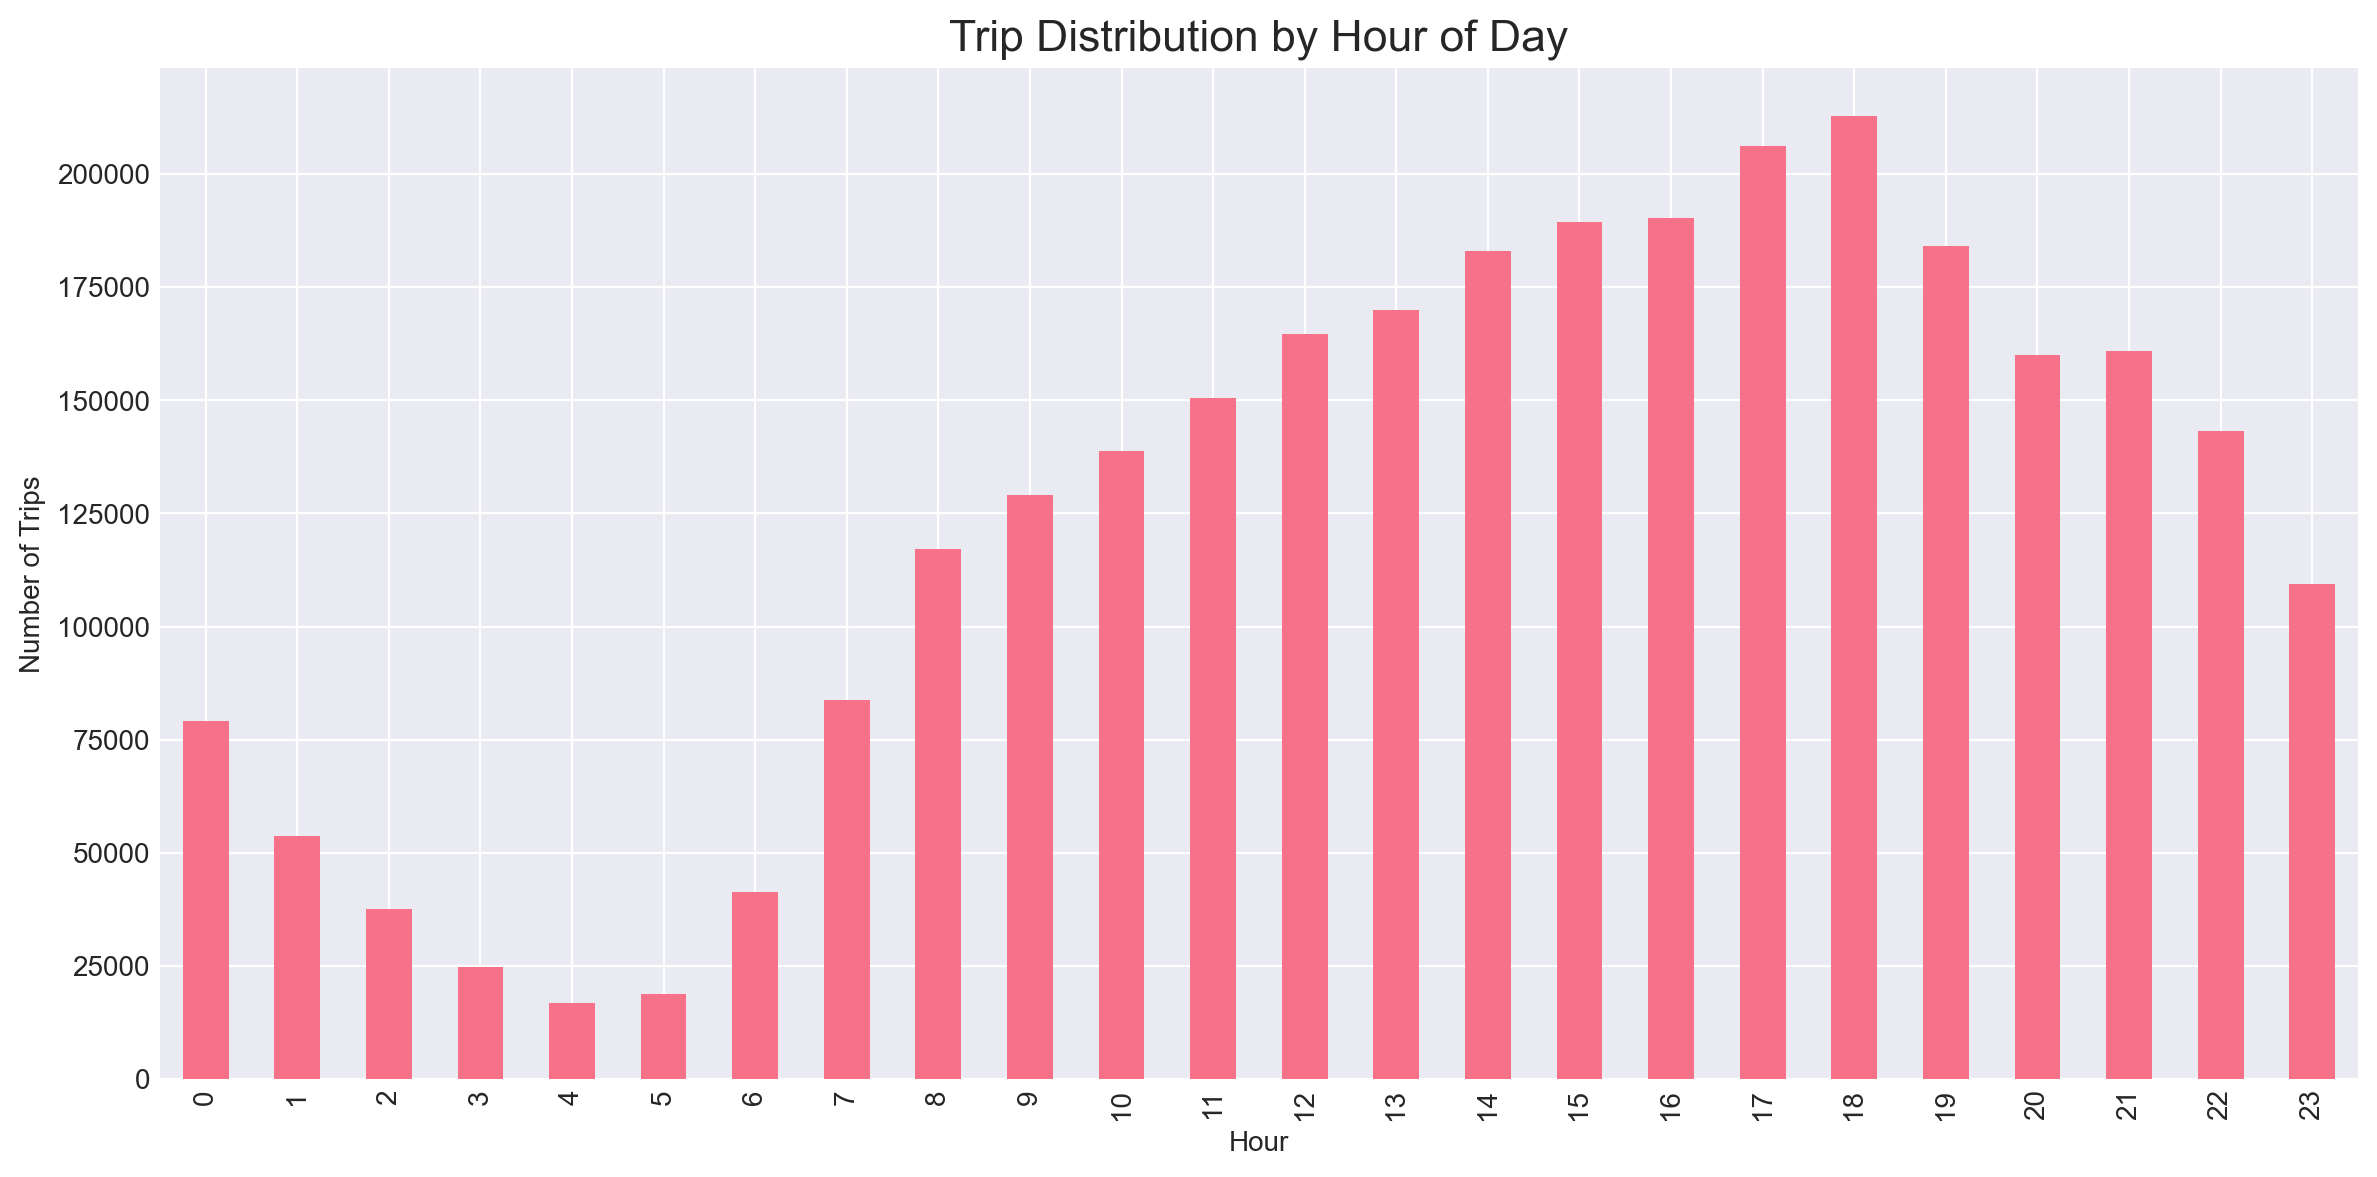

In [23]:
# Trips by hour of day
fig, ax = plt.subplots(figsize=(12, 6))
df['hour'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Trip Distribution by Hour of Day', fontsize=16)
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Trips')
plt.tight_layout()
plt.show()

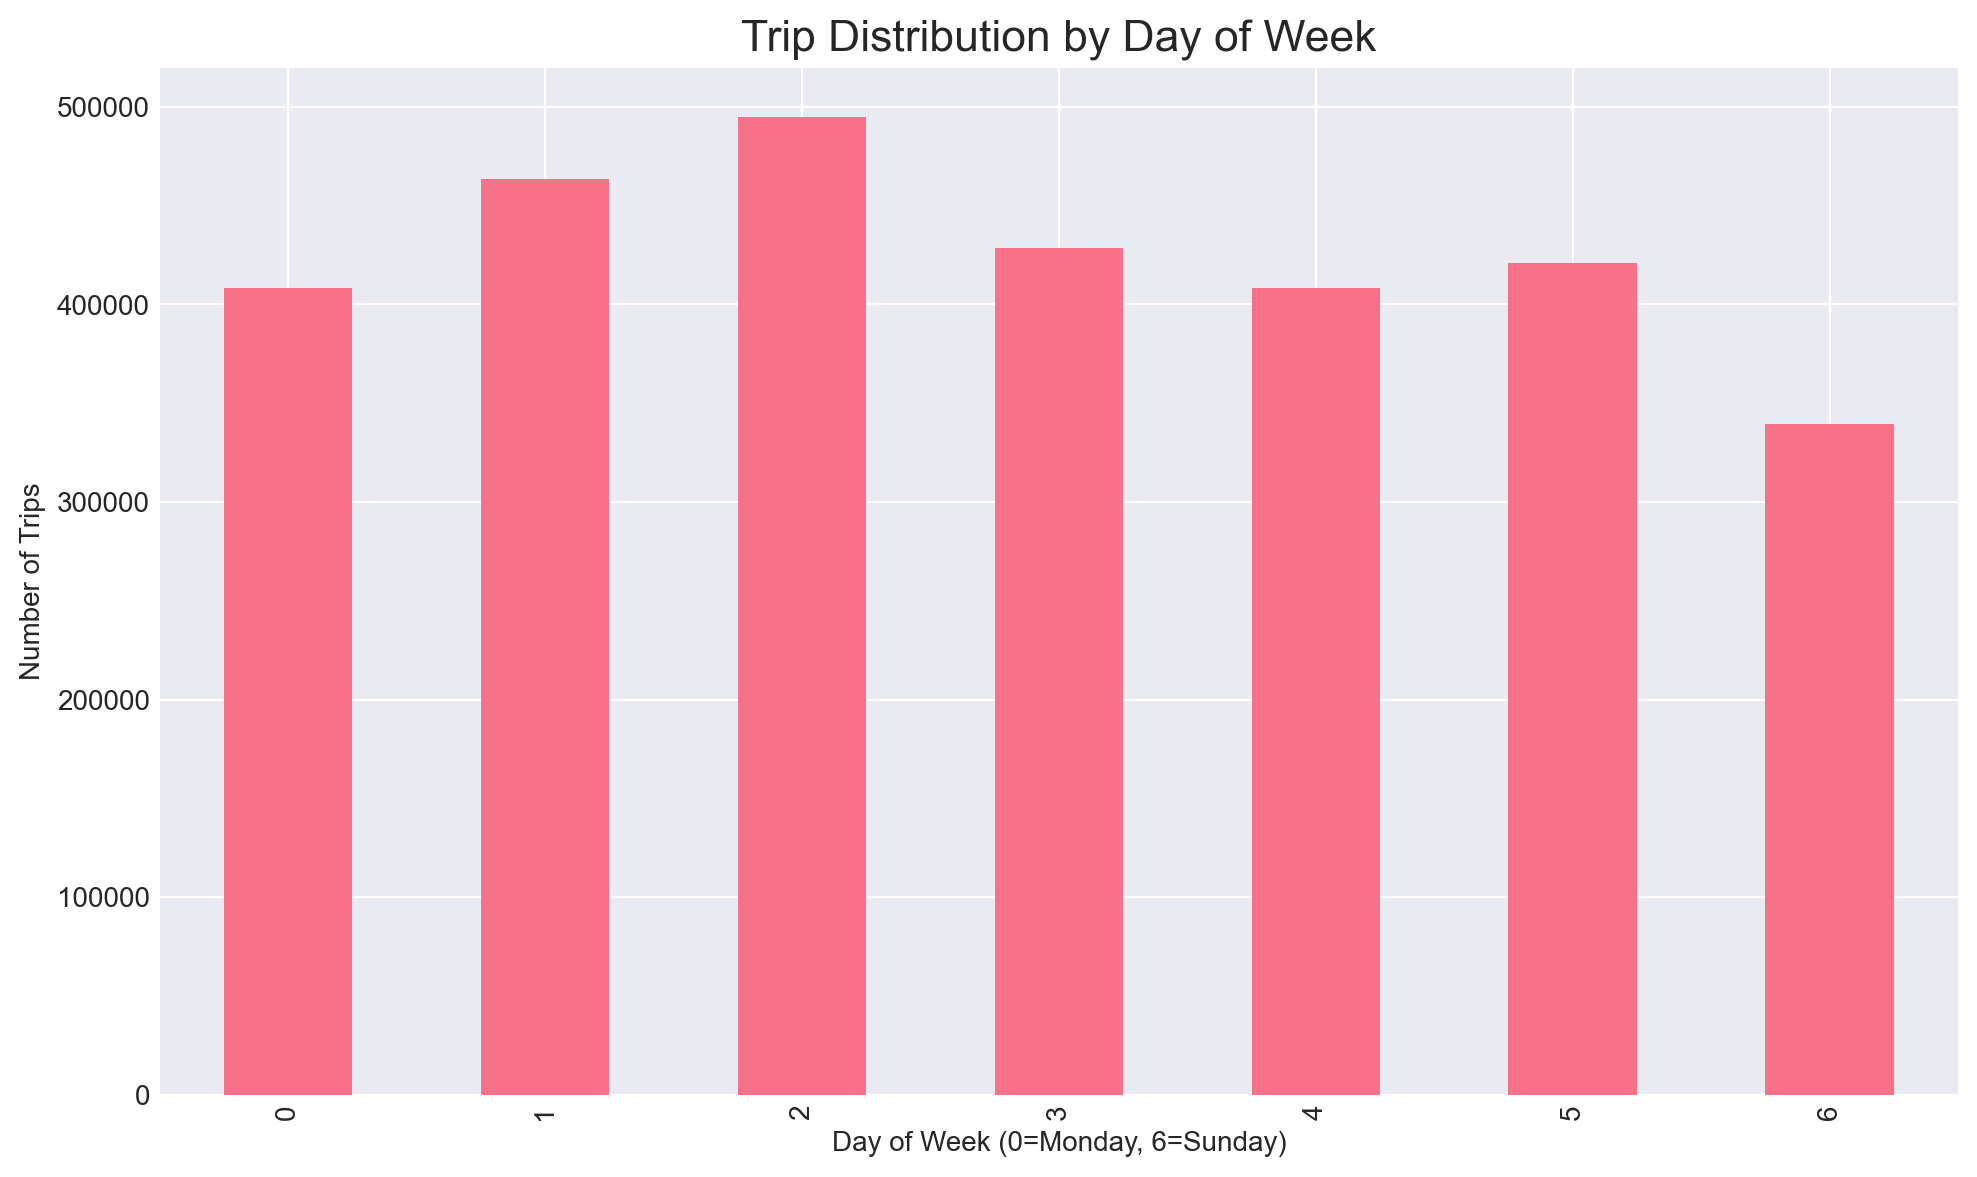

In [24]:
# Trips by day of week
fig, ax = plt.subplots(figsize=(10, 6))
df['day_of_week'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Trip Distribution by Day of Week', fontsize=16)
ax.set_xlabel('Day of Week (0=Monday, 6=Sunday)')
ax.set_ylabel('Number of Trips')
plt.tight_layout()
plt.show()

## 4. Trip Characteristics

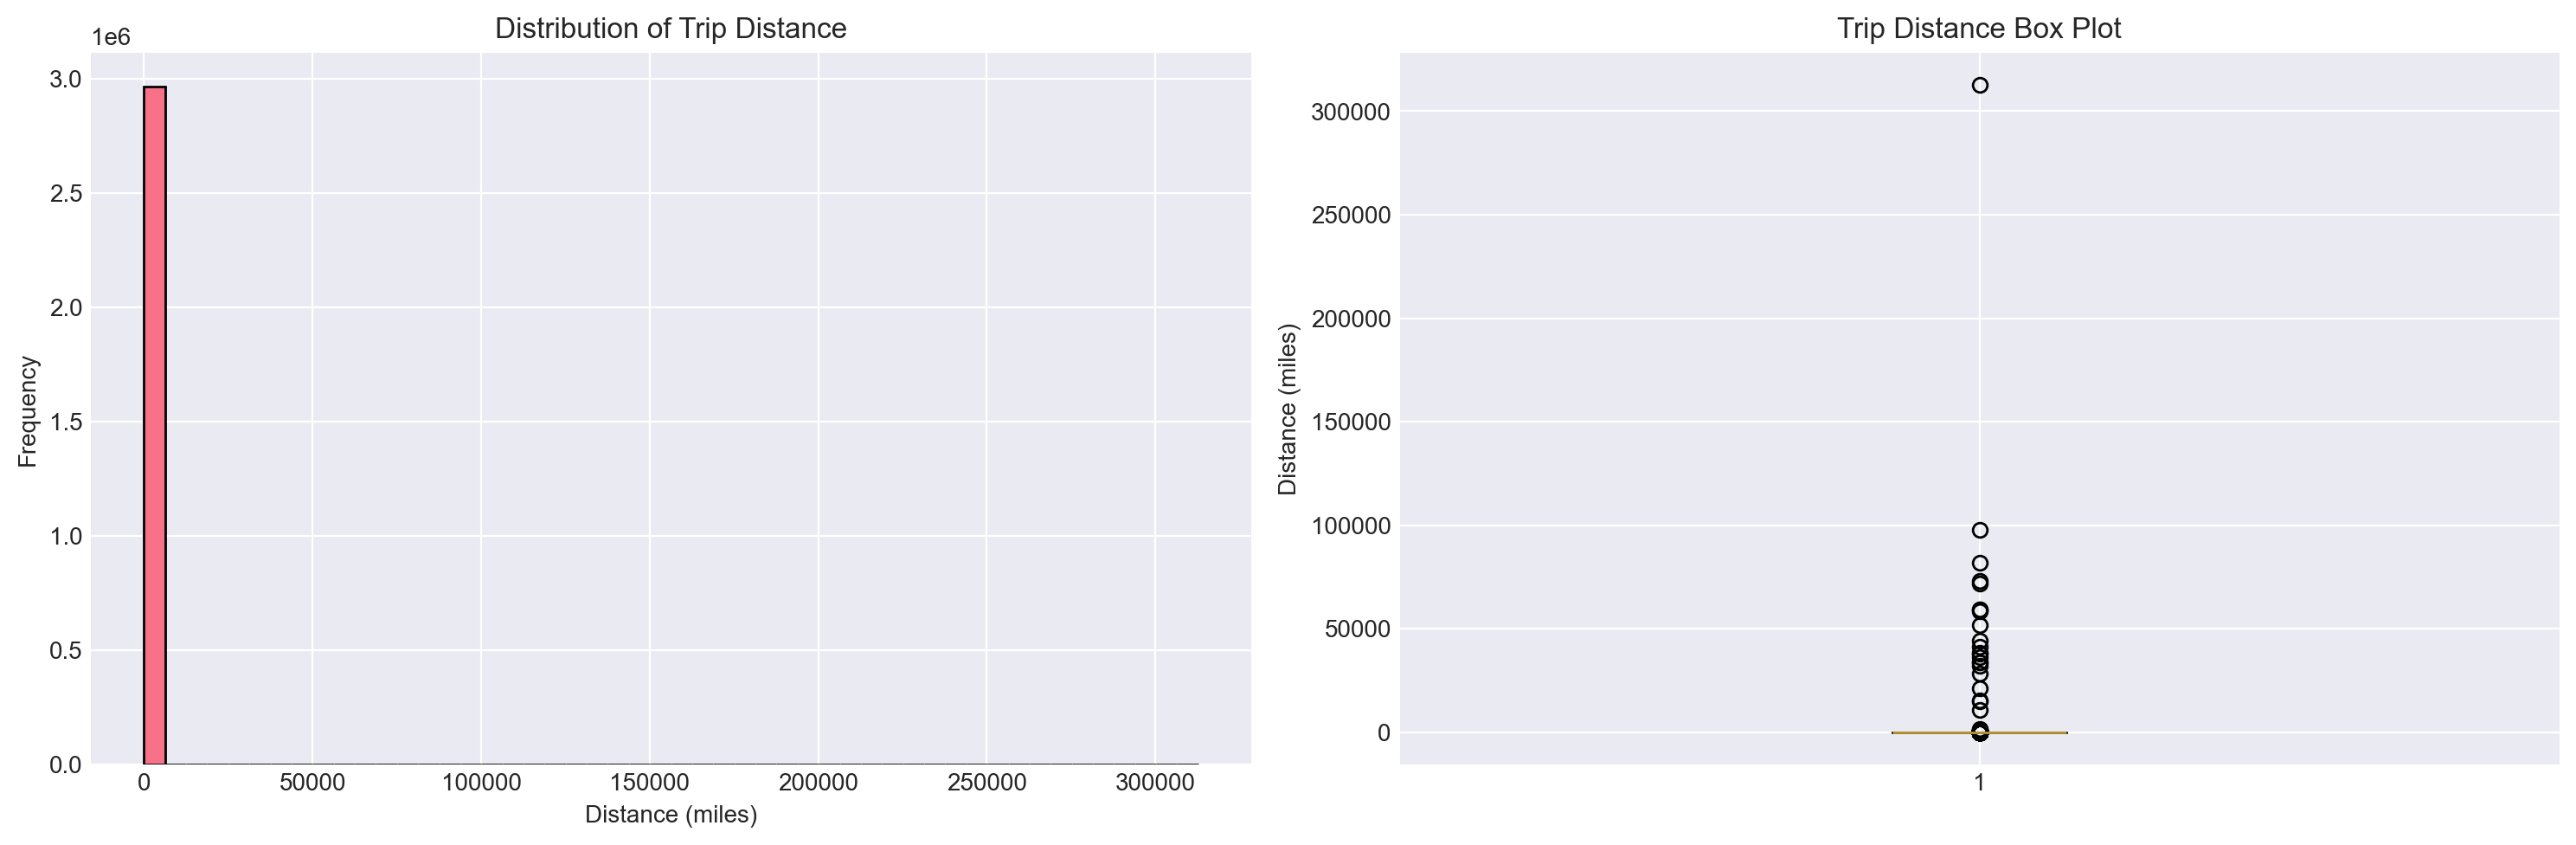

In [25]:
# Distribution of trip distance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['trip_distance'], bins=50, edgecolor='black')
axes[0].set_title('Distribution of Trip Distance')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['trip_distance'].dropna())
axes[1].set_title('Trip Distance Box Plot')
axes[1].set_ylabel('Distance (miles)')

plt.tight_layout()
plt.show()

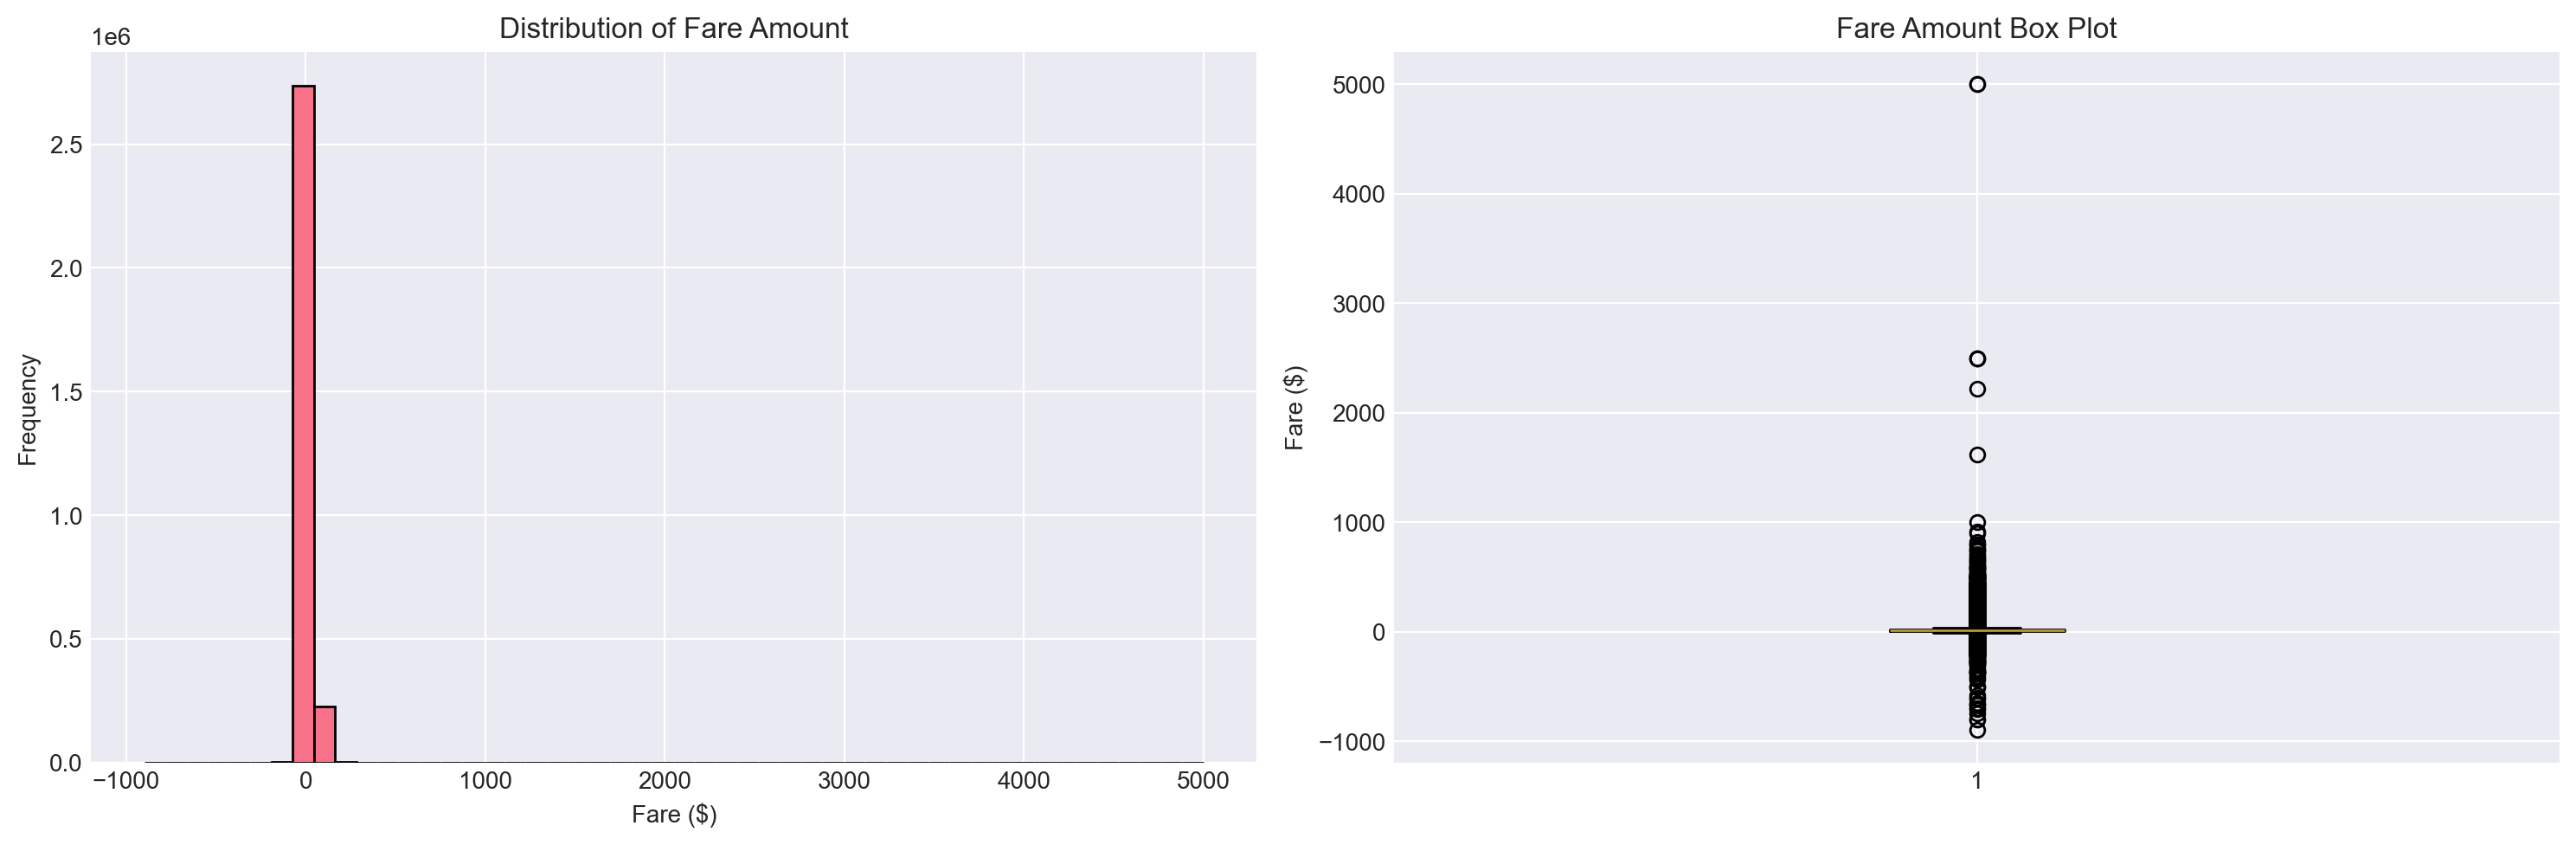

In [26]:
# Distribution of fare amount
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['fare_amount'], bins=50, edgecolor='black')
axes[0].set_title('Distribution of Fare Amount')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['fare_amount'].dropna())
axes[1].set_title('Fare Amount Box Plot')
axes[1].set_ylabel('Fare ($)')

plt.tight_layout()
plt.show()

## 5. Geographic Patterns

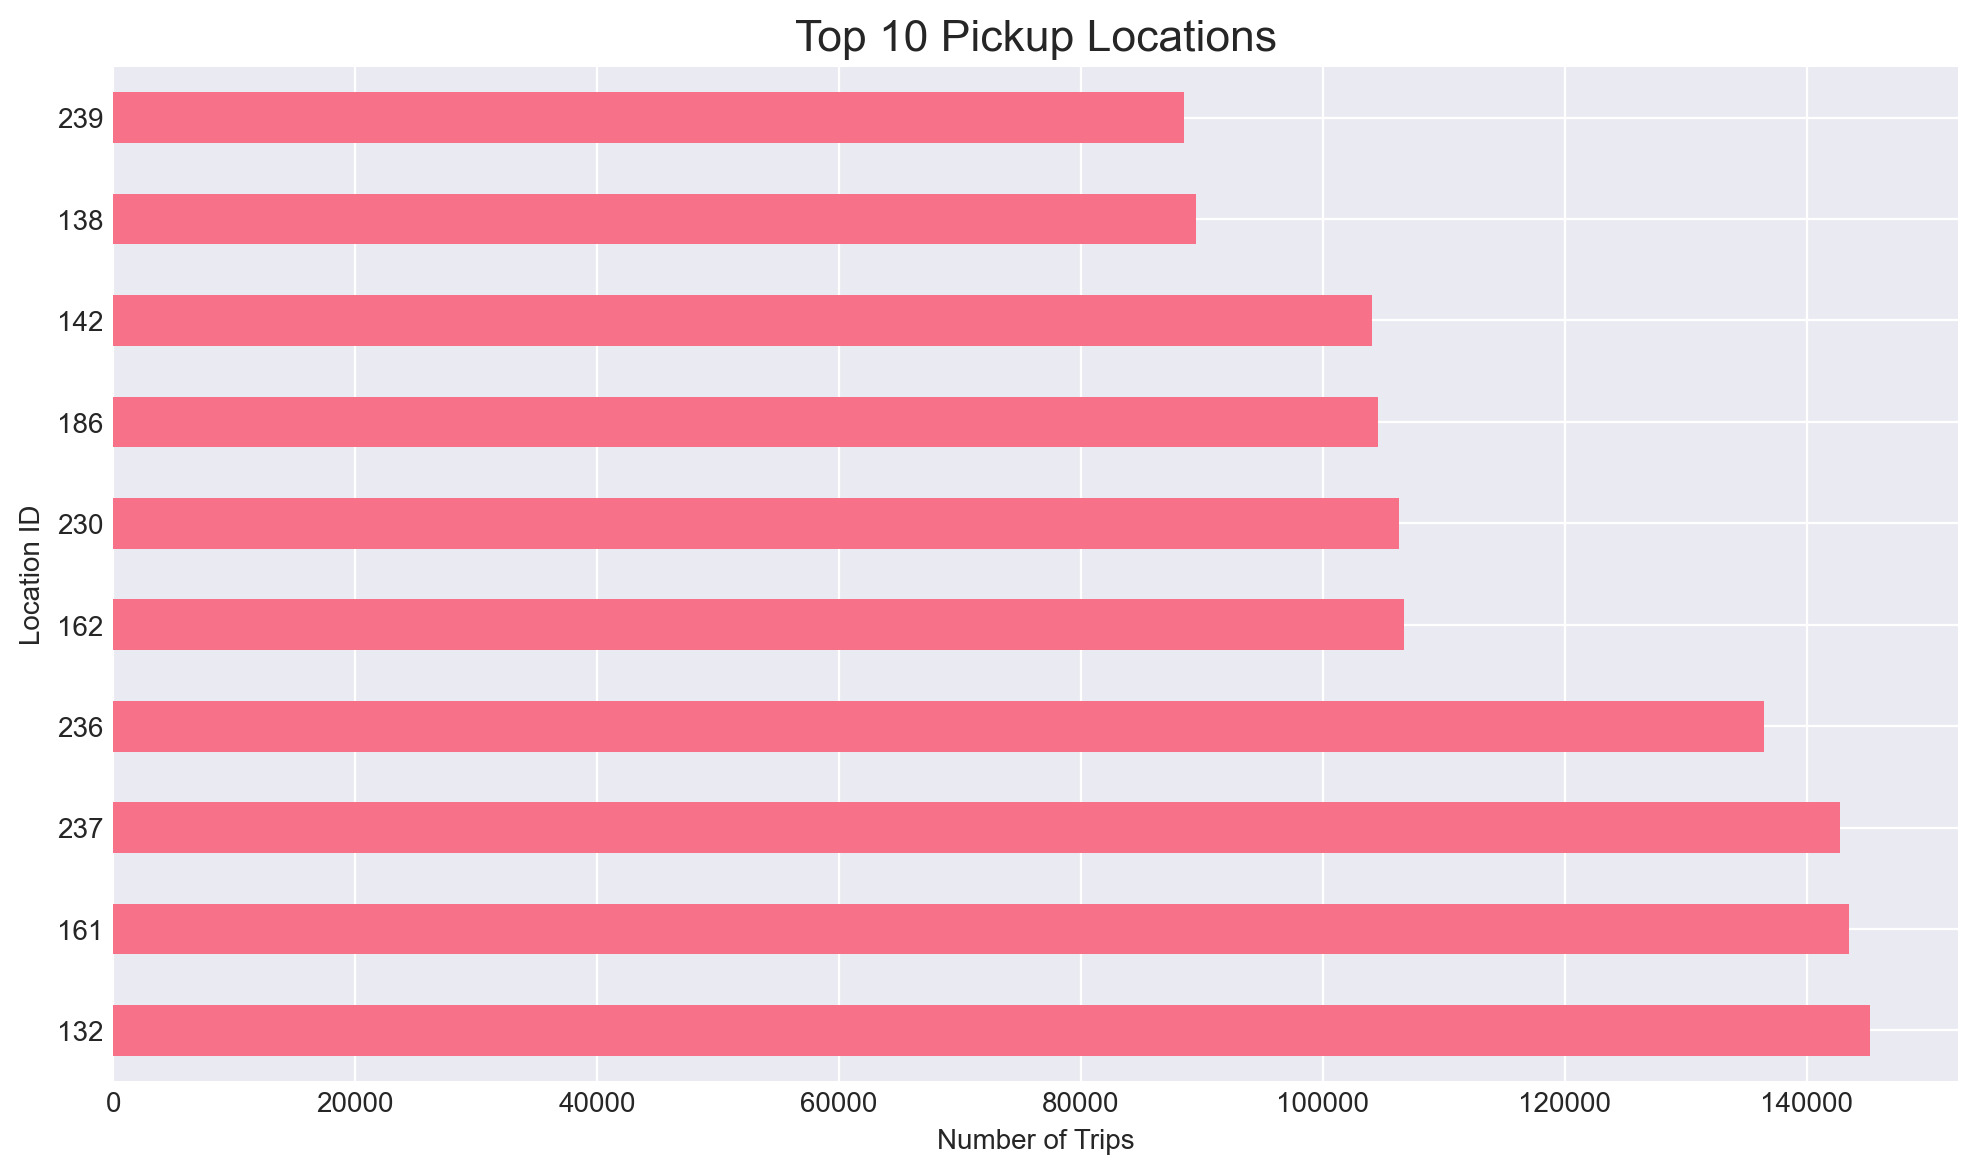

In [27]:
# Top pickup locations
if 'PULocationID' in df.columns:
    top_pickup = df['PULocationID'].value_counts().head(10)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top_pickup.plot(kind='barh', ax=ax)
    ax.set_title('Top 10 Pickup Locations', fontsize=16)
    ax.set_xlabel('Number of Trips')
    ax.set_ylabel('Location ID')
    plt.tight_layout()
    plt.show()